# AIDL A02: Neural Networks and Deep Learning PROJECT

## Student: Zelios Andreas mscaids-0142

## Custom CNN networks

> Words for the dataset can be found [here](https://www.keng.gr/%CE%BB%CE%B5%CE%BE%CE%B9%CE%BA%CF%8C-%CE%B5%CE%BB%CE%BB%CE%B7%CE%BD%CE%B9%CE%BA%CE%AE%CF%82-%CE%BD%CE%BF%CE%B7%CE%BC%CE%B1%CF%84%CE%B9%CE%BA%CE%AE%CF%82-%CE%B3%CE%BB%CF%8E%CF%83%CF%83%CE%B1%CF%82/)  

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
%matplotlib inline
from google.colab import drive

In [2]:
# load data
drive.mount('/content/drive')

def load_data(dataset_dir):
    images = []
    labels = []
    size = 224,224
    index = -1
    for folder in sorted(os.listdir(dataset_dir)):
        index +=1
        for image in os.listdir(dataset_dir + "/" + folder):
            temp_img = cv2.imread(dataset_dir + '/' + folder + '/' + image)
            temp_img = cv2.resize(temp_img, size)
            images.append(temp_img)
            labels.append(index)

    images = np.array(images)
    images = images.astype('float32')/255.0
    labels = utils.to_categorical(labels)

    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.3, random_state = 1)

    print('Loaded', len(x_train),'images for training,','Train data shape =', x_train.shape)
    print('Loaded', len(x_test),'images for testing','Test data shape =', x_test.shape)
    return x_train, x_test, y_train, y_test

dataset_dir = '/content/drive/MyDrive/AIDL02/PROJECT/DATA'

# initial test and training
x_train, x_test, y_train, y_test = load_data(dataset_dir)

Mounted at /content/drive
Loaded 424 images for training, Train data shape = (424, 224, 224, 3)
Loaded 183 images for testing Test data shape = (183, 224, 224, 3)


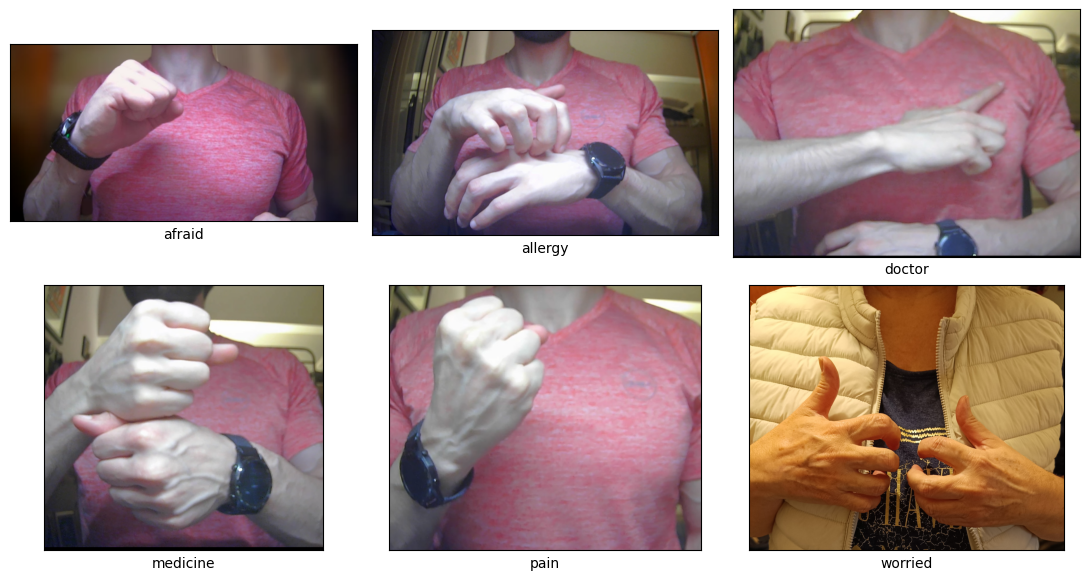

In [3]:
classes = ['afraid', 'allergy', 'doctor', 'medicine', 'pain', 'worried']
plt.figure(figsize=(11, 6))

for i in range(0, 6):
    plt.subplot(2, 3, i+1)
    plt.xticks([])
    plt.yticks([])

    folder_path = dataset_dir + "/" + classes[i]
    first_image_name = sorted(os.listdir(folder_path))[0]
    path = folder_path + "/" + first_image_name

    img = plt.imread(path)
    plt.imshow(img)
    plt.xlabel(classes[i])

plt.tight_layout()
plt.show()

In [4]:
# we now split the training to validation/testing
x_train_n, x_val, y_train_n, y_val = train_test_split(x_train, y_train, test_size = 0.3, random_state = 1)


#1. Custom CNN networks


### Network 1

- Added small batch size, due to small dataset
- Dropout after the layer with parameters (convolutional) to be more generalized and avoid overfitting
- stride is higher in maxpool because we want to drop weights, where in convolutional we want to extract features
- Steadily increase filter size, to first get more general features and then extract more details
- Small size Network because we have small dataset

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
seed = 2
tf.random.set_seed(seed)
np.random.seed(seed)

model = Sequential()

# 224x224 x 3 channels, so 150.528 features each image
model.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model.add(MaxPool2D((2,2), strides=2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.2))
# we have multiple classes, so sigmoid cannot be used
model.add(Dense(len(classes), activation="softmax"))

# power of two to utilize as much memory due to how computers work
# and small, because the dataset is not very large
batch_size = 64
epochs = 200
model_path_one = f'best_model1.h5'
save_model = ModelCheckpoint(model_path_one, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
# shuffle to true to check more data, maybe the model does not see ever let's say doctor
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_1 = model.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1527 - loss: 33.0920   
Epoch 1: val_loss improved from None to 4.86327, saving model to best_model1.h5



Epoch 1: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 6s/step - accuracy: 0.1318 - loss: 40.5069 - val_accuracy: 0.1797 - val_loss: 4.8633
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.1722 - loss: 11.7536
Epoch 2: val_loss improved from 4.86327 to 1.78994, saving model to best_model1.h5



Epoch 2: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1824 - loss: 8.3288 - val_accuracy: 0.2266 - val_loss: 1.7899
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.1888 - loss: 1.9693
Epoch 3: val_loss improved from 1.78994 to 1.78064, saving model to best_model1.h5



Epoch 3: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.2095 - loss: 1.8768 - val_accuracy: 0.2266 - val_loss: 1.7806
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.2883 - loss: 1.7375 
Epoch 4: val_loss improved from 1.78064 to 1.71060, saving model to best_model1.h5


...


Epoch 6: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.6047 - loss: 1.1268 - val_accuracy: 0.6953 - val_loss: 1.1307
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6578 - loss: 0.9171
Epoch 7: val_loss improved from 1.13069 to 0.96904, saving model to best_model1.h5



Epoch 7: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.6757 - loss: 0.8785 - val_accuracy: 0.7500 - val_loss: 0.9690
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8362 - loss: 0.5858
Epoch 8: val_loss improved from 0.96904 to 0.65403, saving model to best_model1.h5



Epoch 8: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 26s 7s/step - accuracy: 0.8514 - loss: 0.5267 - val_accuracy: 0.8047 - val_loss: 0.6540
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8143 - loss: 0.4779
Epoch 9: val_loss improved from 0.65403 to 0.64047, saving model to best_model1.h5



Epoch 9: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.8412 - loss: 0.4233 - val_accuracy: 0.8203 - val_loss: 0.6405
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8777 - loss: 0.3814
Epoch 10: val_loss did not improve from 0.64047
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.9054 - loss: 0.3232 - val_accuracy: 0.8047 - val_loss: 0.6822
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9237 - loss: 0.2393 
Epoch 11: val_loss did not improve from 0.64047
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.9426 - loss: 0.1986 - val_accuracy: 0.8281 - val_loss: 0.6528
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.9517 - loss: 0.1543 
Epoch 12: val_loss improved from 0.64047 to 0.47093, saving model to best_model1.h5



Epoch 12: finished saving model to best_model1.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9628 - loss: 0.1339 - val_accuracy: 0.8516 - val_loss: 0.4709
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9623 - loss: 0.1417
Epoch 13: val_loss did not improve from 0.47093
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.9730 - loss: 0.1130 - val_accuracy: 0.8672 - val_loss: 0.4864
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.9768 - loss: 0.0838
Epoch 14: val_loss did not improve from 0.47093
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.9831 - loss: 0.0681 - val_accuracy: 0.8359 - val_loss: 0.7304
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9863 - loss: 0.0521 
Epoch 15: val_loss did not improve from 0.47093
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.9899 - loss: 0.0420 - val_accuracy: 0.8750 - val_loss: 0.5290
Epoch 16/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9888 - loss: 0.0327 
Epo

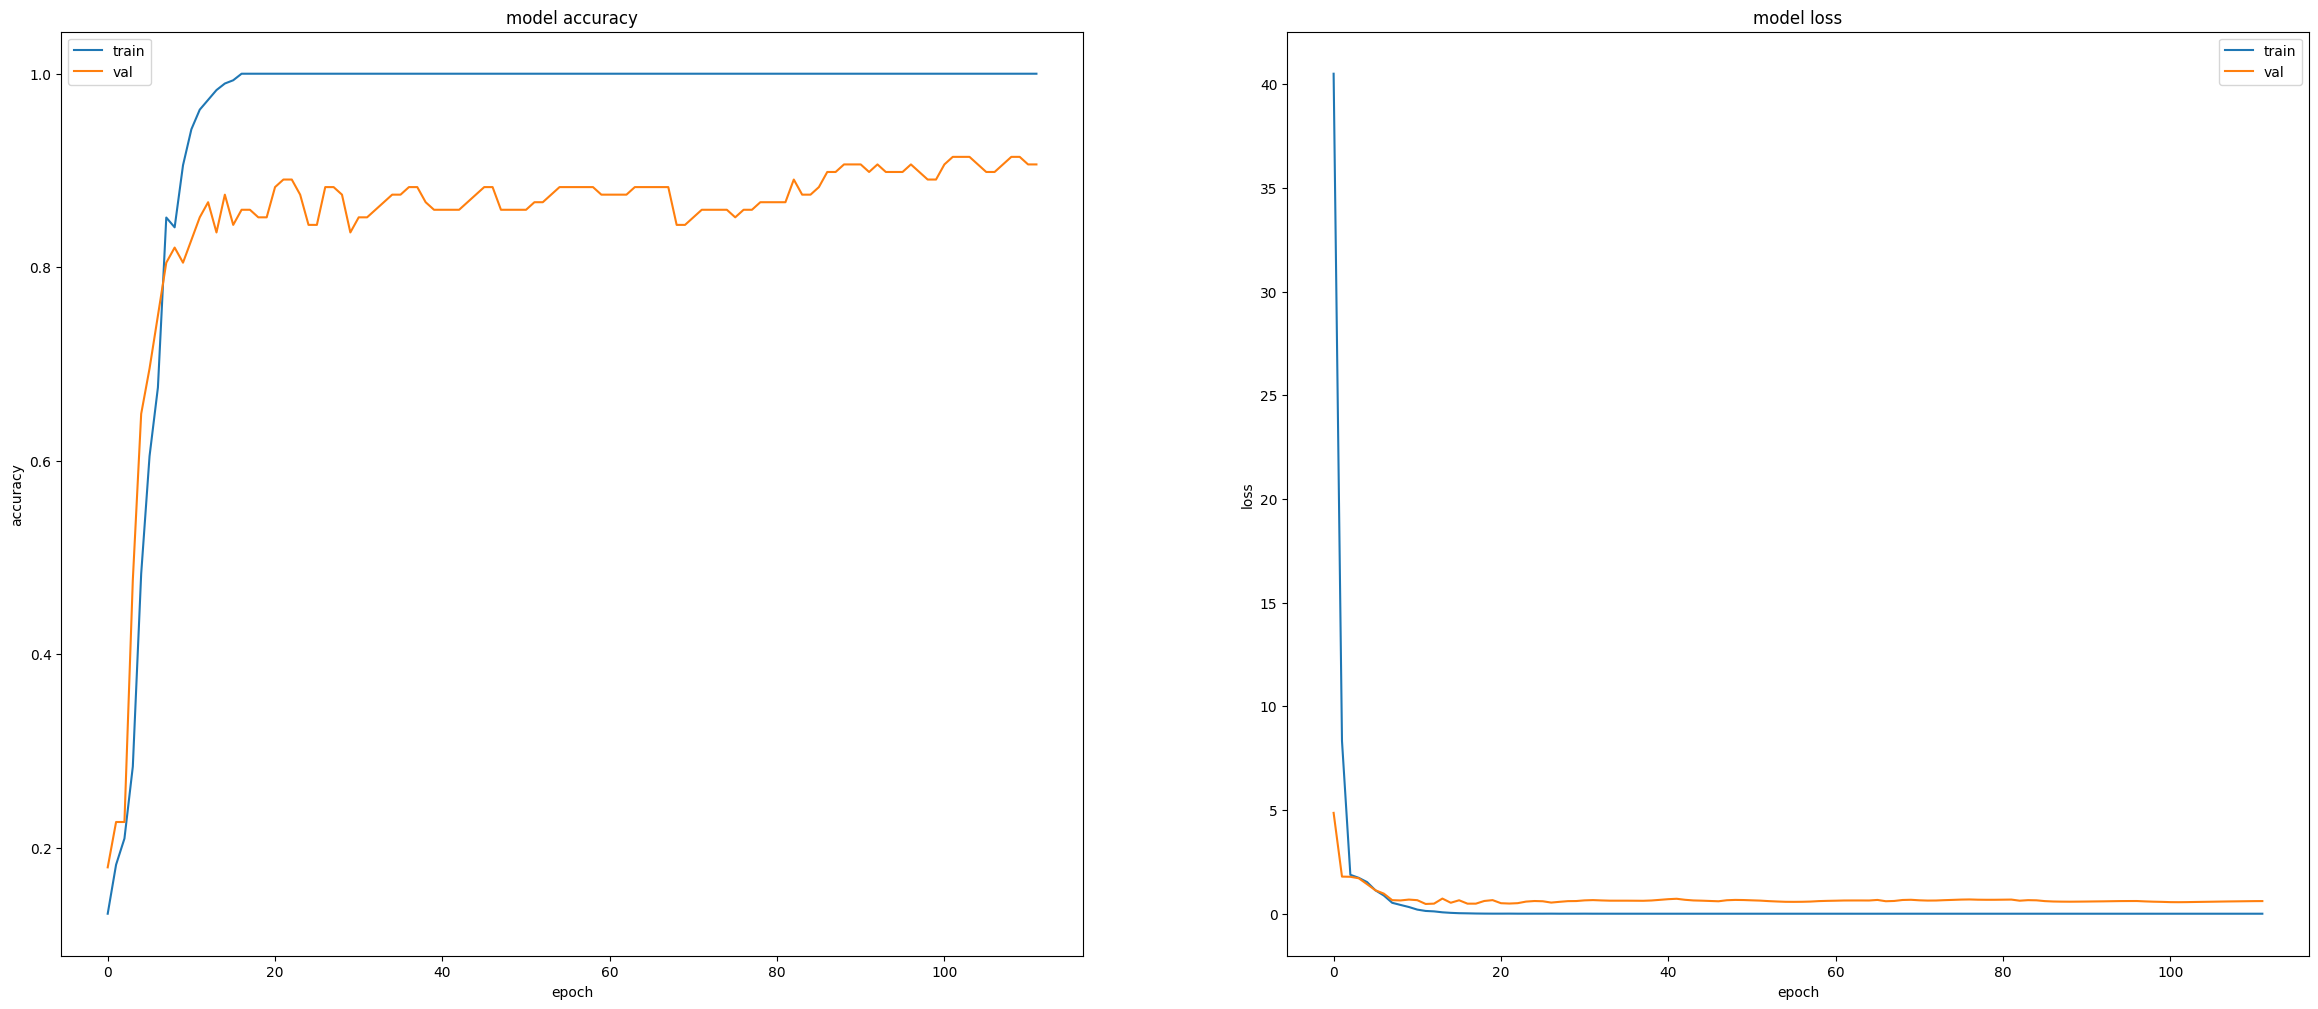

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

The training did overfit, but because we used validation and restore_best_weights, we got the model with the lowest val_loss, so before performance started degrading.

Early stopping was set to be generous (100 epocs) so the model could not really improve as it stopped at 112, where in the diagram, we see that after close to 12 epocs we see that loss flattens.

In [6]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step
Accuracy: 0.8360655737704918
Recal: 0.8252283664048371
F1: 0.8271552090010507
Precision: 0.8469949958508312


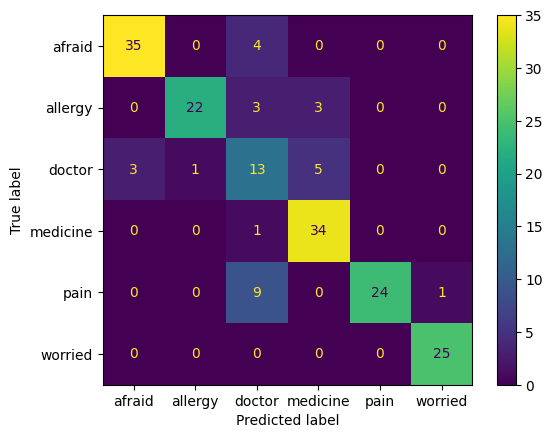

In [ ]:
history_1.model.load_weights('best_model1.h5')

predictions=history_1.model.predict(x_test)

y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()

Seeing the confusion matrix, the metrics seeing above are proven to be correct.

most false negatives can be seen in:
- pain 10/34
- doctor 9/22

we actually se the least false negatives in worried class that also has only one false positive

## Network 2

Differences are:
- **Different optimizer** (rmsprop) just to see it working without stochastic gradient decent as adam uses combination of both
- **Higher epocs**, with combination of *higher patients* to actually use them
- Bigger Network (VGG like)

In [ ]:
model_two = Sequential()

model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_two.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_two.add(MaxPool2D((2,2), strides=2))
model_two.add(Dropout(0.2))

model_two.add(Flatten()) # maybe use GlobalAveragePooling2D()
model_two.add(Dense(units=512, activation='relu'))
model_two.add(Dropout(0.2))

model_two.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_two = f'best_model2.h5'
save_model = ModelCheckpoint(model_path_two, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True)

model_two.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])
history_2 = model_two.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1286 - loss: 2.6734   
Epoch 1: val_loss improved from None to 1.79398, saving model to best_model2.h5



Epoch 1: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 64s 7s/step - accuracy: 0.1419 - loss: 2.5258 - val_accuracy: 0.1172 - val_loss: 1.7940
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.1821 - loss: 1.7986
Epoch 2: val_loss improved from 1.79398 to 1.79085, saving model to best_model2.h5



Epoch 2: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.1655 - loss: 1.7994 - val_accuracy: 0.2266 - val_loss: 1.7909
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2123 - loss: 1.7881
Epoch 3: val_loss improved from 1.79085 to 1.78606, saving model to best_model2.h5



Epoch 3: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2399 - loss: 1.7874 - val_accuracy: 0.1484 - val_loss: 1.7861
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.2316 - loss: 1.7724
Epoch 4: val_loss did not improve from 1.78606
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.2128 - loss: 1.7920 - val_accuracy: 0.1328 - val_loss: 1.8079
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.1998 - loss: 1.8109
Epoch 5: val_loss did not improve from 1.78606
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.2162 - loss: 1.7967 - val_accuracy: 0.1172 - val_loss: 1.8095
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.2513 - loss: 1.7866
Epoch 6: val_loss improved from 1.78606 to 1.76857, saving model to best_model2.h5


...


Epoch 22: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9122 - loss: 0.2688 - val_accuracy: 0.9141 - val_loss: 0.2835
Epoch 23/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9568 - loss: 0.1706
Epoch 23: val_loss did not improve from 0.28348
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.9561 - loss: 0.1749 - val_accuracy: 0.9141 - val_loss: 0.3055
Epoch 24/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.9675 - loss: 0.1742
Epoch 24: val_loss did not improve from 0.28348
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 305ms/step - accuracy: 0.9730 - loss: 0.1217 - val_accuracy: 0.9219 - val_loss: 0.3163
Epoch 25/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9916 - loss: 0.0582
Epoch 25: val_loss did not improve from 0.28348
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.9865 - loss: 0.0594 - val_accuracy: 0.9141 - val_loss: 0.5599
Epoch 26/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9166 - loss: 0.2976
Epoc


Epoch 33: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9730 - loss: 0.0745 - val_accuracy: 0.9375 - val_loss: 0.2798
Epoch 34/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9979 - loss: 0.0287
Epoch 34: val_loss did not improve from 0.27978
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.9932 - loss: 0.0337 - val_accuracy: 0.9062 - val_loss: 0.5094
Epoch 35/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9888 - loss: 0.0327
Epoch 35: val_loss did not improve from 0.27978
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy: 0.9932 - loss: 0.0237 - val_accuracy: 0.9375 - val_loss: 0.4239
Epoch 36/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 36: val_loss did not improve from 0.27978
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9453 - val_loss: 0.4441
Epoch 37/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0026
Epoc


Epoch 52: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9966 - loss: 0.0089 - val_accuracy: 0.9609 - val_loss: 0.2778
Epoch 53/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 0.0010    
Epoch 53: val_loss did not improve from 0.27779
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9609 - val_loss: 0.2893
Epoch 54/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 54: val_loss did not improve from 0.27779
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.9531 - val_loss: 0.3278
Epoch 55/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss: 2.4765e-04
Epoch 55: val_loss did not improve from 0.27779
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 1.0000 - loss: 3.0899e-04 - val_accuracy: 0.9531 - val_loss: 0.3335
Epoch 56/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss


Epoch 56: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 1.0000 - loss: 7.2208e-04 - val_accuracy: 0.9609 - val_loss: 0.2546
Epoch 57/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 57: val_loss did not improve from 0.25457
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9609 - val_loss: 0.2806
Epoch 58/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 1.0000 - loss: 3.2771e-04
Epoch 58: val_loss did not improve from 0.25457
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 1.0000 - loss: 3.0544e-04 - val_accuracy: 0.9688 - val_loss: 0.2756
Epoch 59/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 1.0000 - loss: 1.1950e-04
Epoch 59: val_loss did not improve from 0.25457
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 1.0000 - loss: 1.3629e-04 - val_accuracy: 0.9688 - val_loss: 0.3055
Epoch 60/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 1.0000


Epoch 82: finished saving model to best_model2.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.9291 - loss: 0.5723 - val_accuracy: 0.9375 - val_loss: 0.2432
Epoch 83/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9985 - loss: 0.0109
Epoch 83: val_loss did not improve from 0.24319
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.9966 - loss: 0.0148 - val_accuracy: 0.9062 - val_loss: 0.4952
Epoch 84/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9975 - loss: 0.0060
Epoch 84: val_loss did not improve from 0.24319
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - accuracy: 0.9966 - loss: 0.0079 - val_accuracy: 0.9688 - val_loss: 0.2567
Epoch 85/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 85: val_loss did not improve from 0.24319
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9688 - val_loss: 0.2639
Epoch 86/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 1.0000 - loss: 8.9683e-04

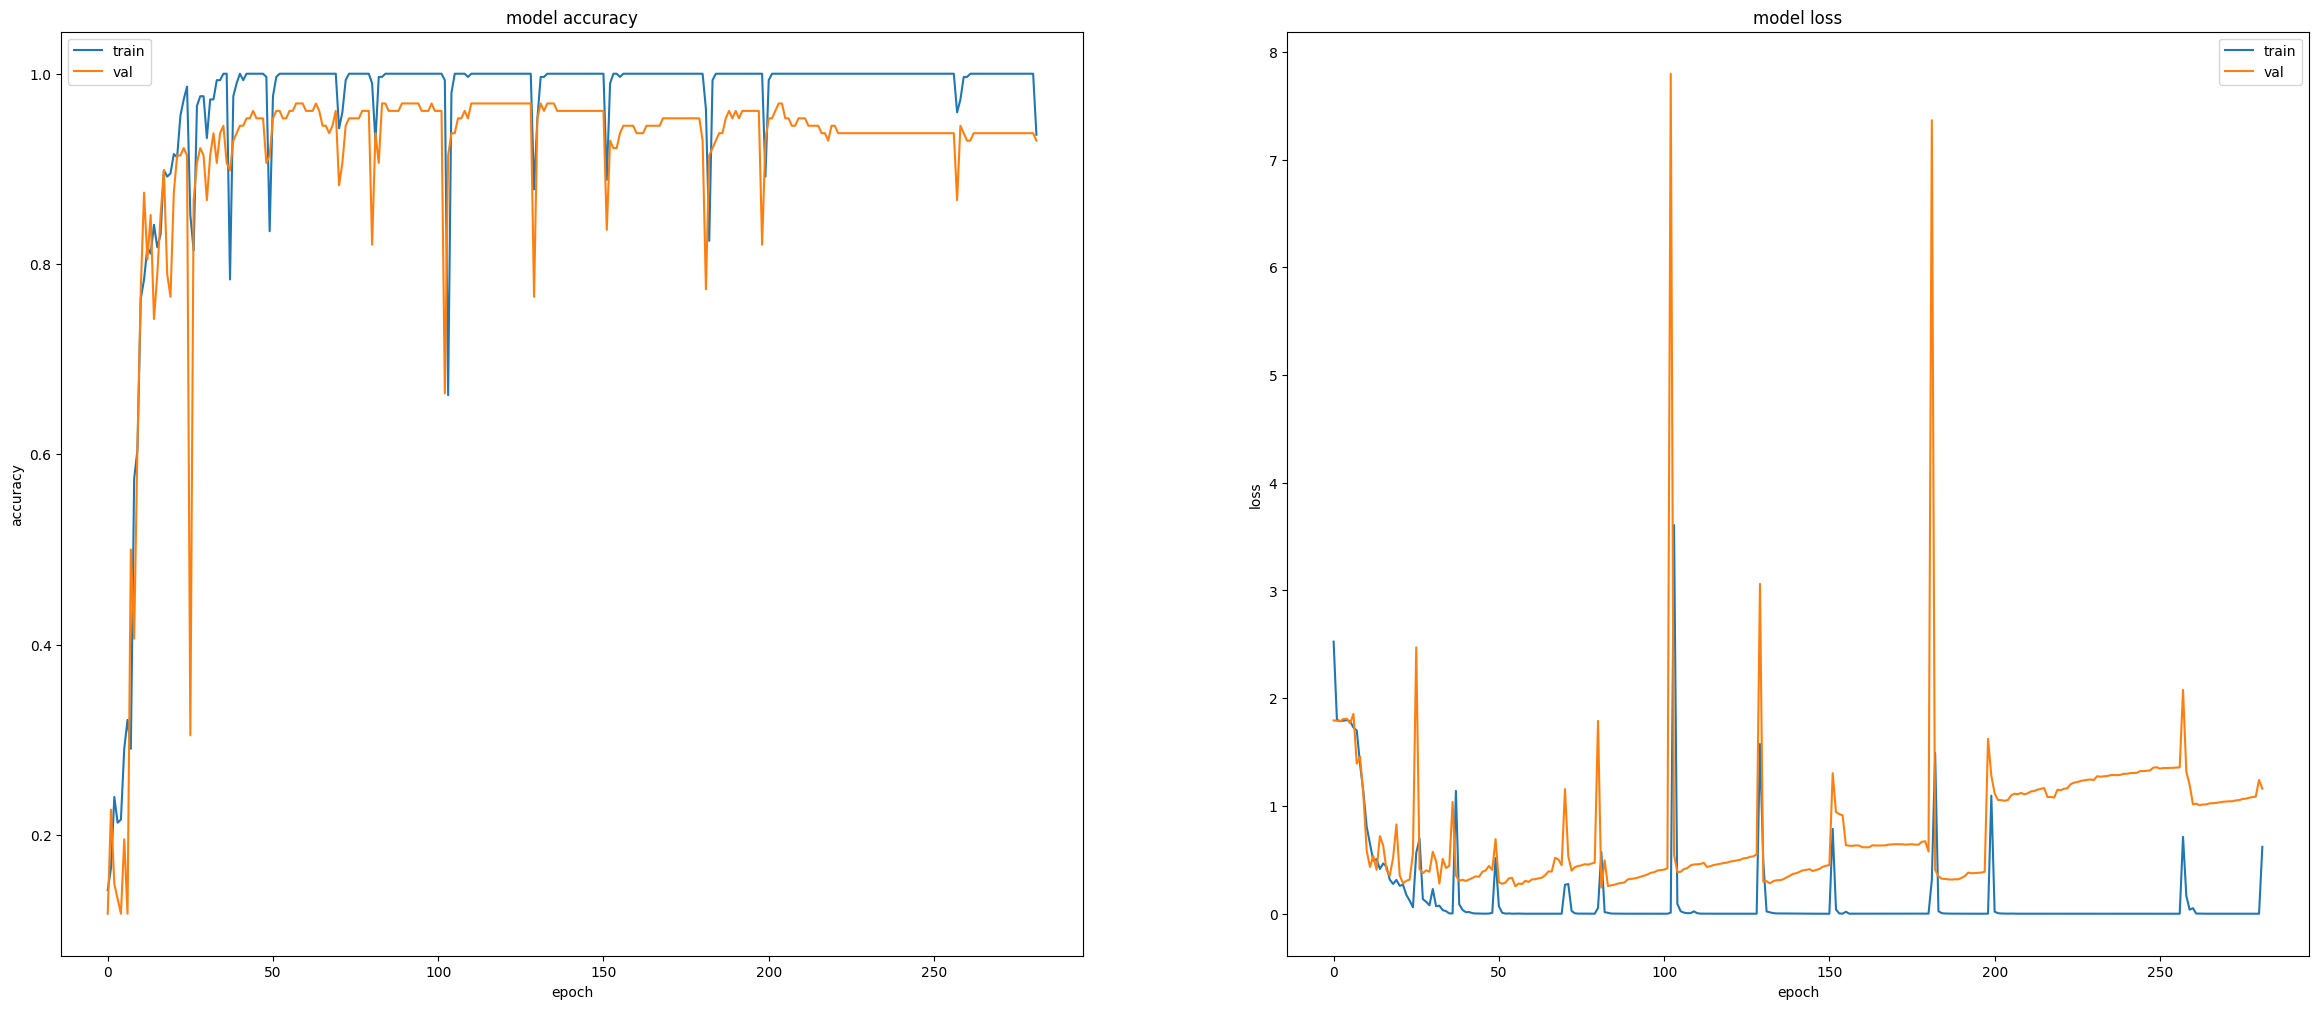

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

The plots are interesting due to the spikes that appear ever so often.

This could be due to the change in the optimizer (rmsprop).

Unlike Adam, it does not keep momentum correlation.

It recalculates the learning rate for each parameter based on how often changes.

Unlike adam, if rms fixes the learning rate for a batch and the next batch has very large gradients we will se another spike, if not the learning rate is adapted so it will appear more smoothly.

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step
Accuracy: 0.9398907103825137
Recal: 0.9375041625041626
F1: 0.9406539458850589
Precision: 0.9484105273578957


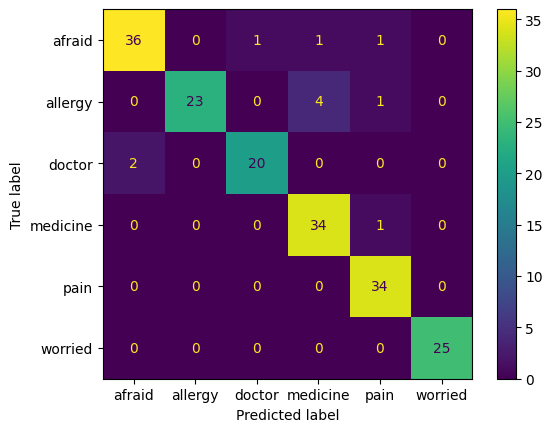

In [ ]:
history_2.model.load_weights('best_model2.h5')

predictions2=history_2.model.predict(x_test)

y_pred_classes = np.argmax(predictions2, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm2 = confusion_matrix(y_true_classes, y_pred_classes)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classes)
disp2.plot()

The results appear to be better, the false negatives were reduced across all classes.

While the results are valid due to the saving of the best weights, maybe the training method is not reliable due to the overshoot, if we retrain we might not land in the same point between spikes

## Network 3

- added BatchNormalization to avoid Exploding Gradients
- smaller patience to avoid overfitting
- added back Adam as optimizer
- used GlobalAveragePooling2D instead of Flattening
- seeing the results of the ASL challenge, I also added a scheduler to alter the learning rate. We will use Exponential Decay as taught in class

In [8]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

In [ ]:
model_three = Sequential()

model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu', input_shape=(224,224,3)))
model_three.add(Conv2D(32, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(Conv2D(64, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(Conv2D(128, (3,3), strides=1, padding='same', activation='relu'))
model_three.add(BatchNormalization())
model_three.add(MaxPool2D((2,2), strides=2))
model_three.add(Dropout(0.2))

model_three.add(GlobalAveragePooling2D())
model_three.add(Dense(units=512, activation='relu'))
model_three.add(Dropout(0.2))
model_three.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 300
model_path_three = f'best_model3.h5'
save_model = ModelCheckpoint(model_path_three, save_best_only=True, monitor='val_loss', mode='min', verbose=2)
early_stop = EarlyStopping(monitor='val_loss', patience=120, restore_best_weights=True)
lr_schedule = ExponentialDecay(initial_learning_rate=1e-3, decay_steps=100, decay_rate=0.96, staircase=False)

model_three.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=lr_schedule), metrics=["accuracy"])
history_3 = model_three.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle=True, validation_data=(x_val, y_val), callbacks=[save_model, early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1633 - loss: 1.8923   
Epoch 1: val_loss improved from None to 1.79717, saving model to best_model3.h5



Epoch 1: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1926 - loss: 1.8572 - val_accuracy: 0.0938 - val_loss: 1.7972
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3314 - loss: 1.6226
Epoch 2: val_loss did not improve from 1.79717
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 313ms/step - accuracy: 0.3041 - loss: 1.6526 - val_accuracy: 0.1562 - val_loss: 1.7999
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.3901 - loss: 1.5225
Epoch 3: val_loss did not improve from 1.79717
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - accuracy: 0.3986 - loss: 1.5115 - val_accuracy: 0.1328 - val_loss: 1.7982
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.4462 - loss: 1.4470
Epoch 4: val_loss did not improve from 1.79717
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - accuracy: 0.4459 - loss: 1.4348 - val_accuracy: 0.2031 - val_loss: 1.7988
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.4671 - loss: 1.3191
Epoch 5: va


Epoch 114: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 319ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.6016 - val_loss: 1.6784
Epoch 115/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 0.0027
Epoch 115: val_loss improved from 1.67836 to 1.47955, saving model to best_model3.h5



Epoch 115: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.6328 - val_loss: 1.4795
Epoch 116/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 1.0000 - loss: 0.0032
Epoch 116: val_loss improved from 1.47955 to 1.32998, saving model to best_model3.h5


...


Epoch 170: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 1.0000 - loss: 3.9487e-04 - val_accuracy: 0.9609 - val_loss: 0.1564
Epoch 171/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 6.6712e-04
Epoch 171: val_loss improved from 0.15640 to 0.13030, saving model to best_model3.h5



Epoch 171: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 1.0000 - loss: 7.2590e-04 - val_accuracy: 0.9609 - val_loss: 0.1303
Epoch 172/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 1.0000 - loss: 5.8221e-04
Epoch 172: val_loss improved from 0.13030 to 0.11374, saving model to best_model3.h5



Epoch 172: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 322ms/step - accuracy: 1.0000 - loss: 7.5421e-04 - val_accuracy: 0.9531 - val_loss: 0.1137
Epoch 173/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 1.0000 - loss: 5.2785e-04
Epoch 173: val_loss did not improve from 0.11374
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 1.0000 - loss: 5.7077e-04 - val_accuracy: 0.9453 - val_loss: 0.1174
Epoch 174/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 1.0000 - loss: 5.9870e-04
Epoch 174: val_loss did not improve from 0.11374
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 1.0000 - loss: 5.2938e-04 - val_accuracy: 0.9609 - val_loss: 0.1219
Epoch 175/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 3.3456e-04
Epoch 175: val_loss did not improve from 0.11374
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 1.0000 - loss: 3.5739e-04 - val_accuracy: 0.9609 - val_loss: 0.1293
Epoch 176/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


Epoch 186: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 1.0000 - loss: 4.4294e-04 - val_accuracy: 0.9375 - val_loss: 0.1048
Epoch 187/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 1.0000 - loss: 3.6282e-04
Epoch 187: val_loss improved from 0.10478 to 0.05284, saving model to best_model3.h5



Epoch 187: finished saving model to best_model3.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - accuracy: 1.0000 - loss: 5.1437e-04 - val_accuracy: 0.9844 - val_loss: 0.0528
Epoch 188/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 1.0000 - loss: 3.0797e-04
Epoch 188: val_loss did not improve from 0.05284
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 1.0000 - loss: 3.0074e-04 - val_accuracy: 0.9766 - val_loss: 0.0698
Epoch 189/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 1.0000 - loss: 3.4291e-04
Epoch 189: val_loss did not improve from 0.05284
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 1.0000 - loss: 3.2392e-04 - val_accuracy: 0.9688 - val_loss: 0.0994
Epoch 190/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 1.0000 - loss: 4.6145e-04
Epoch 190: val_loss did not improve from 0.05284
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 1.0000 - loss: 4.9670e-04 - val_accuracy: 0.9688 - val_loss: 0.1203
Epoch 191/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step

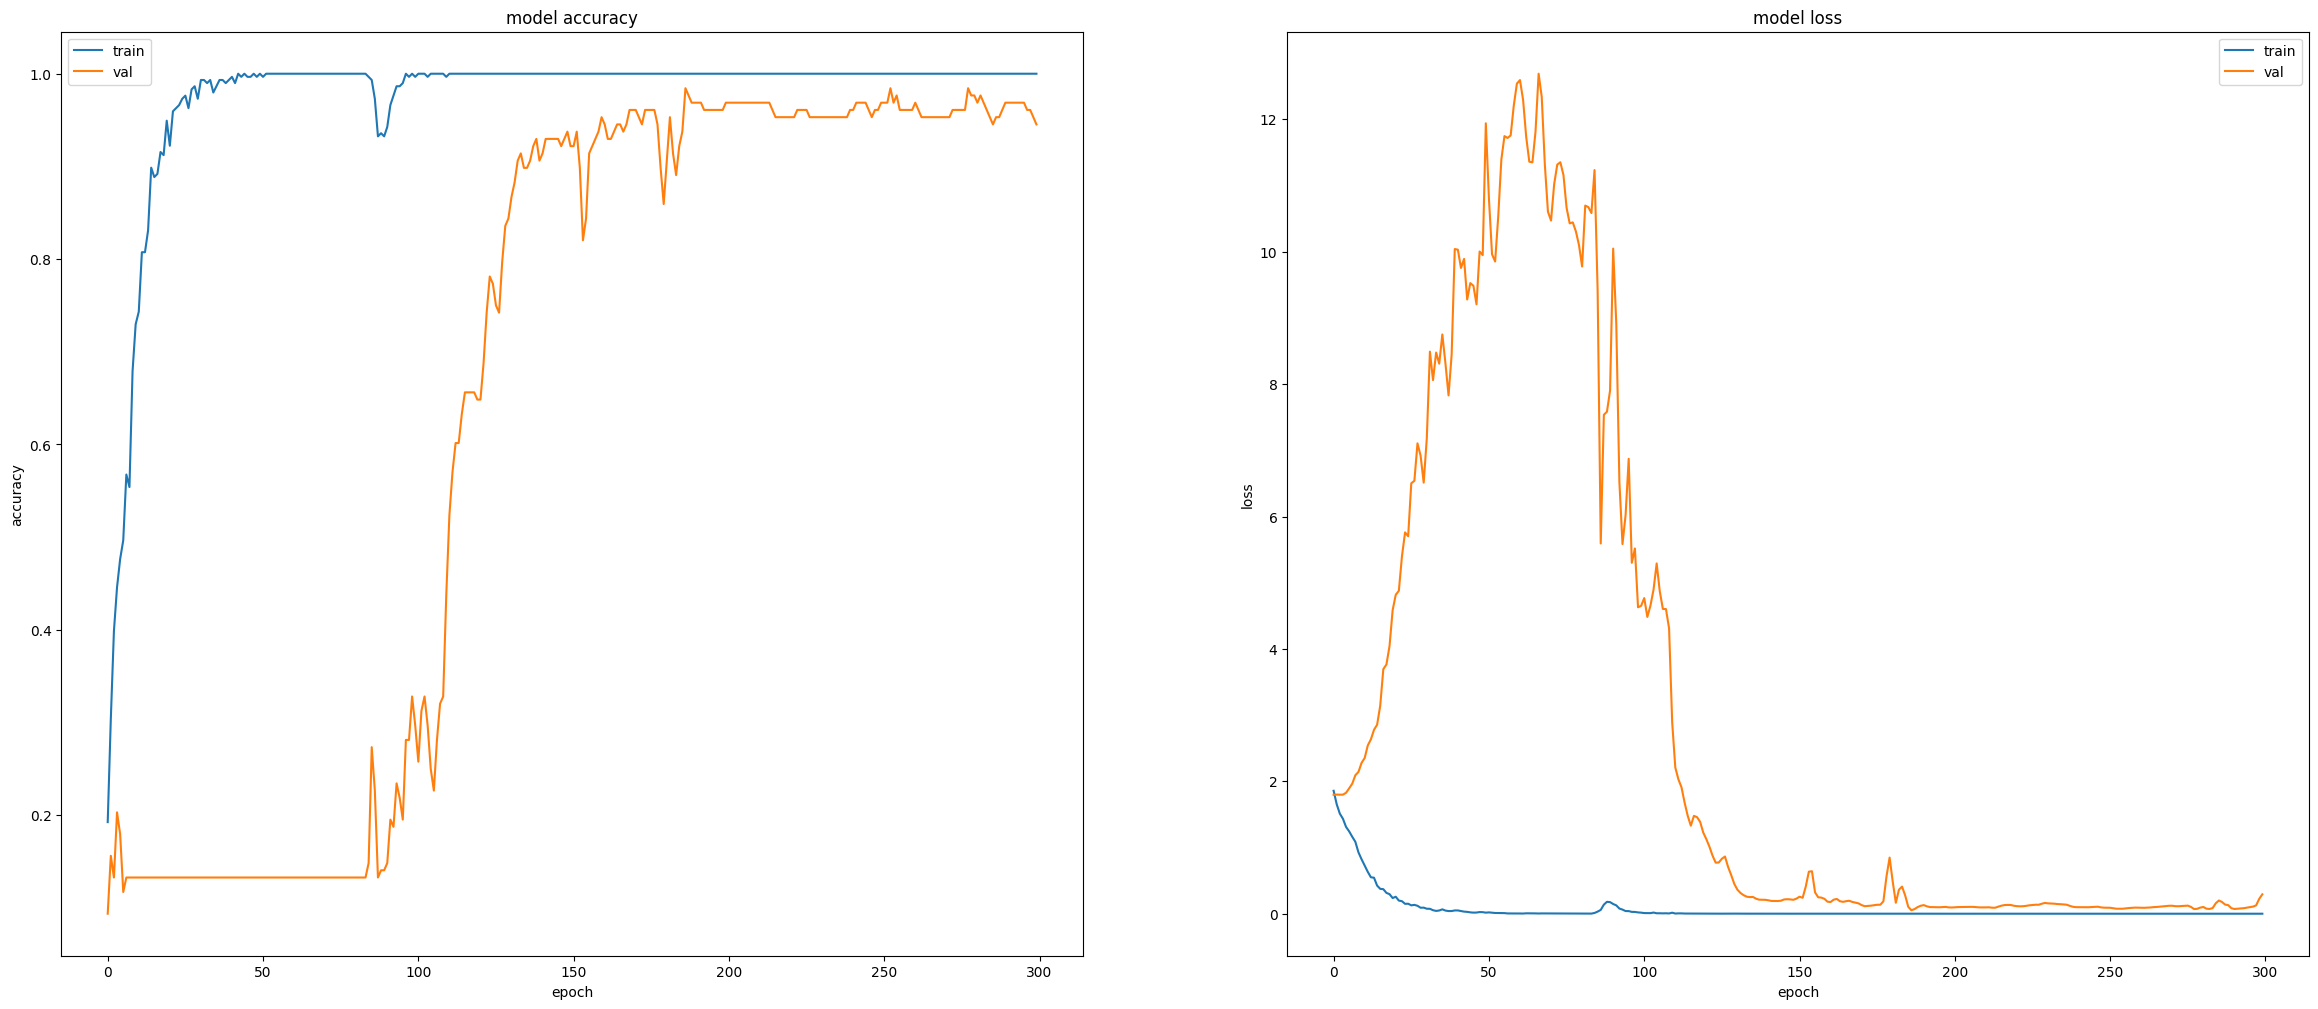

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

We can see the effect of ExponentialDecay in the validation results.

The huge val loss at the start is the learning rate being too high, we see that the model tries to adjust it with drops and around epoc 100 we see a grater difference.

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step
Accuracy: 0.9562841530054644
Recal: 0.9595062127415068
F1: 0.9552115715418766
Precision: 0.9533538769452083


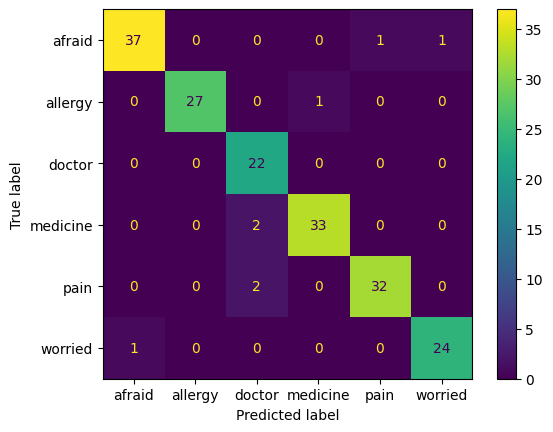

In [ ]:
history_3.model.load_weights('best_model3.h5')

predictions3=history_3.model.predict(x_test)

y_pred_classes = np.argmax(predictions3, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm3 = confusion_matrix(y_true_classes, y_pred_classes)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=classes)
disp3.plot()

These results are the best ones so far.

The overall false negatives dropped once again, the main difference is:

- False negatives
  - Increased false negatives:
    - 1 more in medicine class
    - 2 more in pain class
    - 1 more in worried class
  - Decreased false negatives:
    - 1 less in afraid class
    - 4 less in allergy class
    - 2 less in doctor class

- False Positives
  - Increased false Positives:
    - 3 more in doctor class
    - 1 more in worried class
  - Decreased false Positives:
    - 1 less in afraid class
    - 4 less in allergy class
    - 2 less in pain class

Overall we have more balanced and less false negatives and also show in the recall metric

 0.9375041625041626 to 0.9595062127415068

For our specific classes we would like to predict all of them correct, but mostly not mix very different cases because it might be proven dangerous.

The most crucial is medicine and allergy.

The 1 missclassification of allergy was medicine, which is good, someone would likely understand that medicine might correlate to allergy problem.

The 2 missclassifications in medicine is more worrysome because doctor does not directly correlate to that, if the person is looking for their perscription they might not get it in time.



#2. Transfer learning

## 1. VGG16

In [ ]:
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.optimizers import Adam

In [ ]:
model_vgg = Sequential()
model_vgg.add(VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3)))
model_vgg.add(Flatten())
model_vgg.add(Dense(512, activation='relu'))
model_vgg.add(Dense(len(classes), activation='softmax'))

learning_rate = 0.0001
batch_size = 64
epochs = 5

adam = Adam(learning_rate=learning_rate)
save_model_vgg = ModelCheckpoint('best_model_vgg.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_vgg.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_vgg = model_vgg.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_vgg])

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.1650 - loss: 1.9771  
Epoch 1: val_loss improved from None to 1.67481, saving model to best_model_vgg.h5



Epoch 1: finished saving model to best_model_vgg.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 166s 22s/step - accuracy: 0.2027 - loss: 1.9082 - val_accuracy: 0.3516 - val_loss: 1.6748
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.4925 - loss: 1.5179
Epoch 2: val_loss improved from 1.67481 to 0.77417, saving model to best_model_vgg.h5



Epoch 2: finished saving model to best_model_vgg.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5236 - loss: 1.4027 - val_accuracy: 0.8906 - val_loss: 0.7742
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 910ms/step - accuracy: 0.8101 - loss: 0.6848
Epoch 3: val_loss improved from 0.77417 to 0.25803, saving model to best_model_vgg.h5



Epoch 3: finished saving model to best_model_vgg.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8277 - loss: 0.5643 - val_accuracy: 0.9062 - val_loss: 0.2580
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.9726 - loss: 0.1241
Epoch 4: val_loss improved from 0.25803 to 0.18501, saving model to best_model_vgg.h5



Epoch 4: finished saving model to best_model_vgg.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9764 - loss: 0.1245 - val_accuracy: 0.9531 - val_loss: 0.1850
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.9934 - loss: 0.0244
Epoch 5: val_loss improved from 0.18501 to 0.15535, saving model to best_model_vgg.h5



Epoch 5: finished saving model to best_model_vgg.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9932 - loss: 0.0225 - val_accuracy: 0.9531 - val_loss: 0.1553


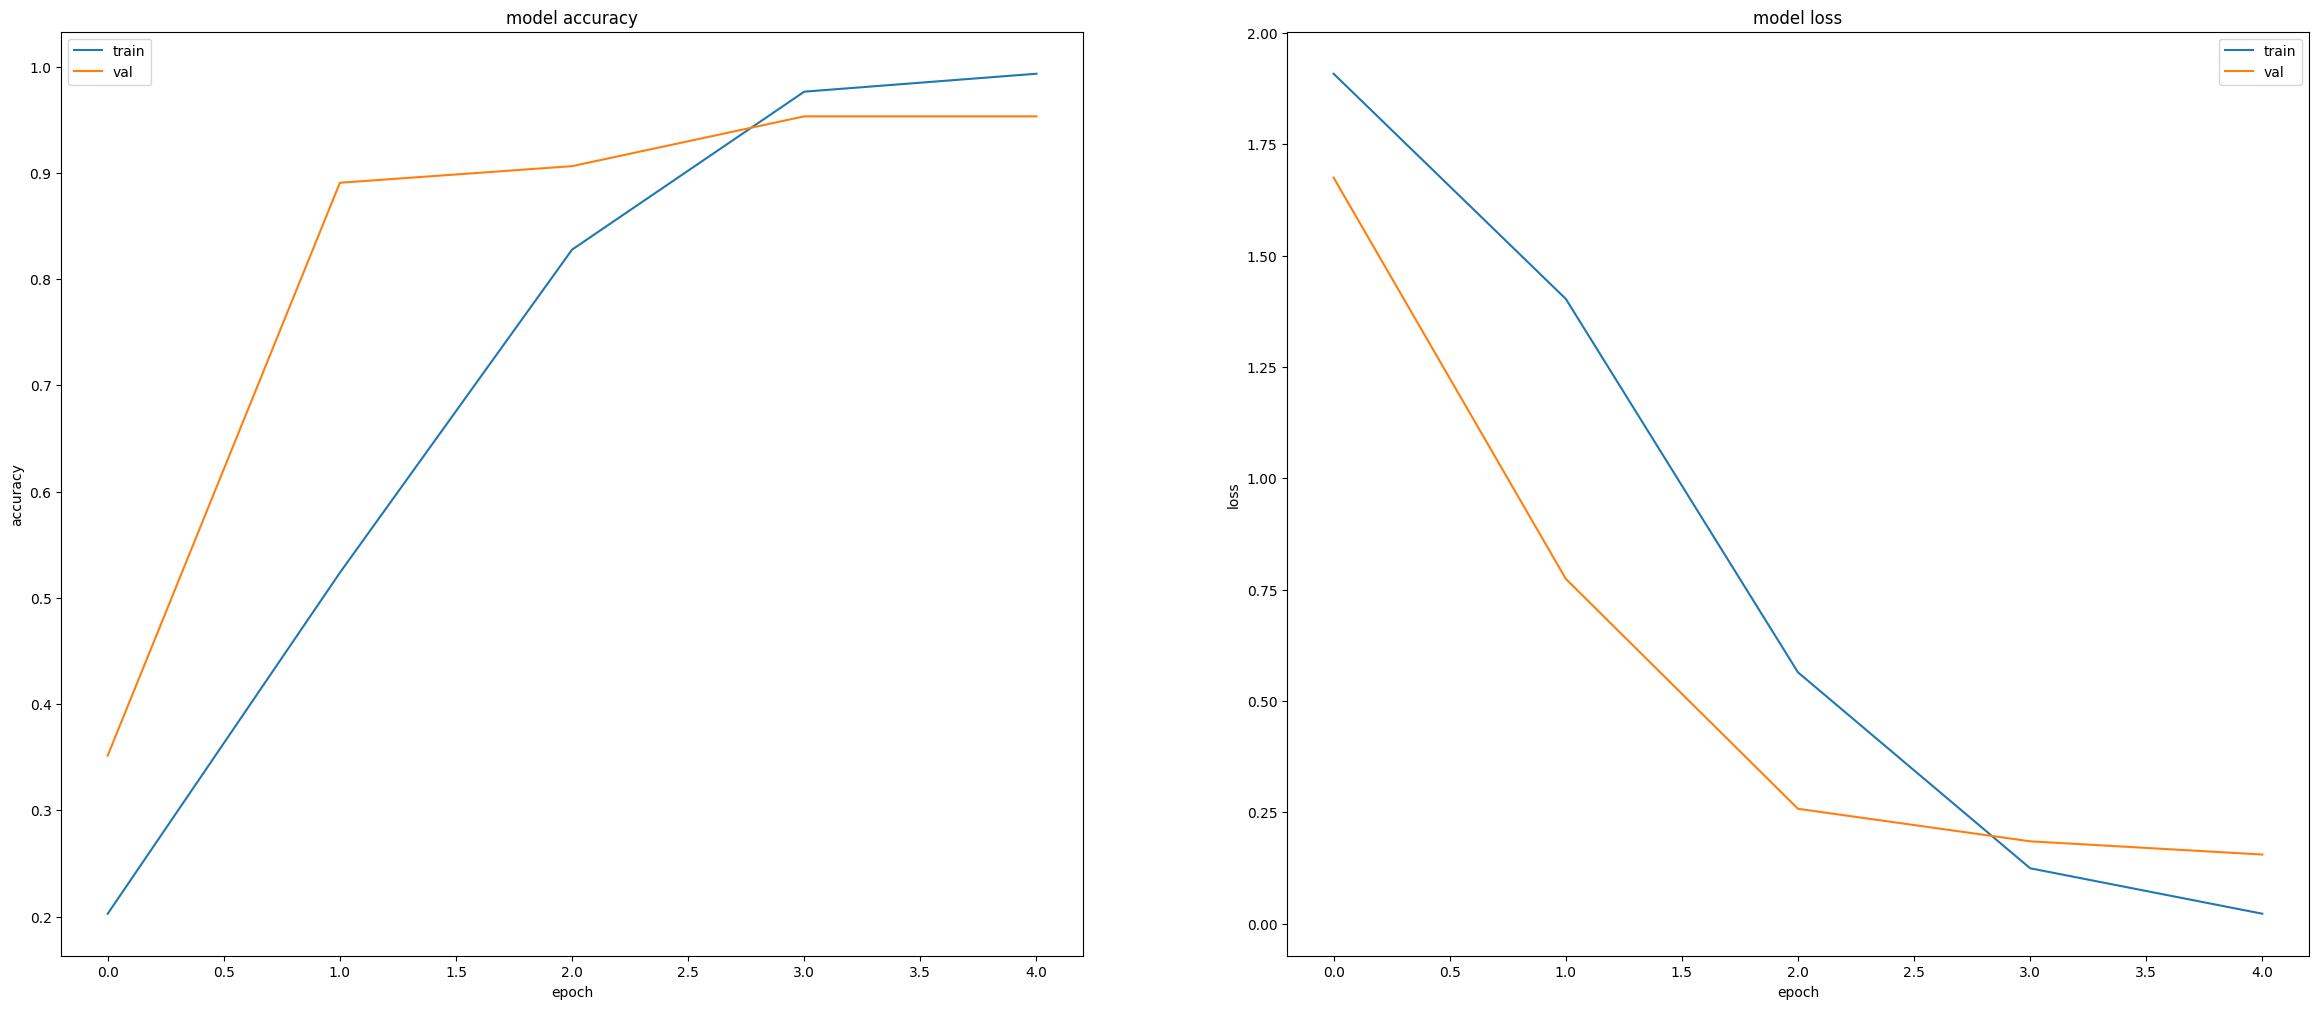

In [ ]:
plt.figure(figsize=(29, 12))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')

6/6 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step
Accuracy: 0.9672131147540983
Recal: 0.9672105672105672
F1: 0.9656043981559014
Precision: 0.9655834764530417


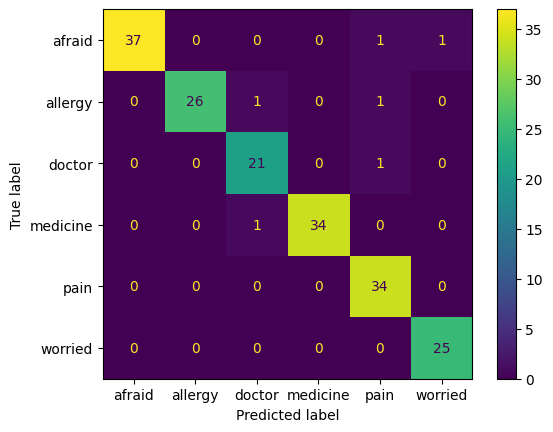

In [ ]:
history_vgg.model.load_weights('best_model_vgg.h5')

predictionsvgg=history_vgg.model.predict(x_test)

y_pred_classes = np.argmax(predictionsvgg, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm4 = confusion_matrix(y_true_classes, y_pred_classes)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=classes)
disp4.plot()

The results are very good, our best accuracy so far.

Comparing it to our best convolutional we see:

- False negatives
  - Increased false negatives:
    - 1 more in allergy class
    - 1 more in doctor class
  - Decreased false negatives:
    - 1 less in medicine class
    - 2 less in pain class
    - 1 less in worried class

- False Positives
  - Increased false Positives:
    - 2 more in pain class
  - Decreased false Positives:
    - 1 less in afraid class
    - 2 less in doctor class
    - 1 less in medicine class

The overall false negative/positives dropped. Now as far as our concerning classes of medicine and allergy, we see

- The one false negative for allergy, shifted from medicine to 1 doctor and 1 pain.

  This is not desirable at all, so in that regard the model would need to be adjusted.

- The good thing is that we got one less false negative for the medicine class, still the missclassification happens to be doctor, this would again be better if it fallen in allergy class


## 2. ResNet

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

** This is a raw model without frozen weights, it is not the one used for the project, but it shows why I went to the second **

In [ ]:
resNet=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

model_res = Sequential()
model_res.add(resNet)

model_res.add(Flatten())
model_res.add(Dense(220, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(120, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(60, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(len(classes), activation='softmax'))


learning_rate = 0.0001
batch_size = 32
epochs = 5

adam = Adam(learning_rate=learning_rate)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
save_model_res = ModelCheckpoint('best_model_res.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_res.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_res = model_res.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_res, early_stop])

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1878 - loss: 4.6305   
Epoch 1: val_loss improved from None to 1.89450, saving model to best_model_res.h5



Epoch 1: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 164s 10s/step - accuracy: 0.1757 - loss: 4.4667 - val_accuracy: 0.1562 - val_loss: 1.8945
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.3020 - loss: 3.6592
Epoch 2: val_loss improved from 1.89450 to 1.83999, saving model to best_model_res.h5



Epoch 2: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.3209 - loss: 3.6830 - val_accuracy: 0.1484 - val_loss: 1.8400
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.2822 - loss: 3.6581
Epoch 3: val_loss improved from 1.83999 to 1.80649, saving model to best_model_res.h5



Epoch 3: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.3243 - loss: 3.3495 - val_accuracy: 0.1484 - val_loss: 1.8065
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3500 - loss: 2.7680
Epoch 4: val_loss improved from 1.80649 to 1.79945, saving model to best_model_res.h5



Epoch 4: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3378 - loss: 2.7905 - val_accuracy: 0.1484 - val_loss: 1.7994
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3497 - loss: 2.5410
Epoch 5: val_loss did not improve from 1.79945
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step - accuracy: 0.3615 - loss: 2.3485 - val_accuracy: 0.1250 - val_loss: 1.8182


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Accuracy: 0.1912568306010929
Recal: 0.16666666666666666
F1: 0.053516819571865444
Precision: 0.03187613843351548


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


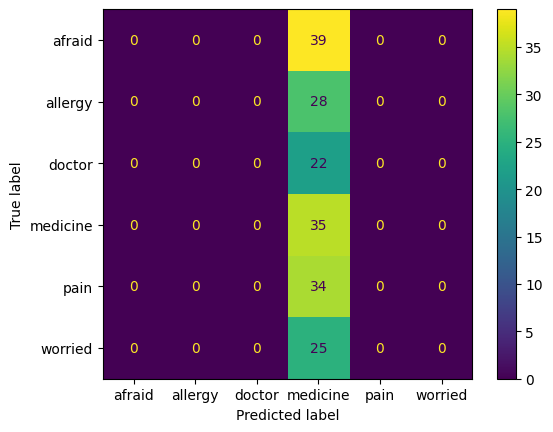

In [ ]:
history_res.model.load_weights('best_model_res.h5')

predictionsres=history_res.model.predict(x_test)

y_pred_classes = np.argmax(predictionsres, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm5 = confusion_matrix(y_true_classes, y_pred_classes)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=classes)
disp5.plot()

This model runs very poorly for all classes except medicine.

Accuracy is overall low in all accounts

So because I thought that the model features were much different from mine, I wanted to take them frozen and keep training my model

In [ ]:
resNet=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resNet.trainable = False
model_res = Sequential()
model_res.add(resNet)

model_res.add(Flatten())
model_res.add(Dense(512, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(len(classes), activation='softmax'))


learning_rate = 0.0001
batch_size = 64
epochs = 120

adam = Adam(learning_rate=learning_rate)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
save_model_res = ModelCheckpoint('best_model_res.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_res.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_res = model_res.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_res, early_stop])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1624 - loss: 3.8490   
Epoch 1: val_loss improved from None to 2.80171, saving model to best_model_res.h5



Epoch 1: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.1622 - loss: 4.1223 - val_accuracy: 0.1484 - val_loss: 2.8017
Epoch 2/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.1548 - loss: 2.7465
Epoch 2: val_loss improved from 2.80171 to 1.70310, saving model to best_model_res.h5



Epoch 2: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.1554 - loss: 2.6982 - val_accuracy: 0.2109 - val_loss: 1.7031
Epoch 3/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2652 - loss: 1.9230
Epoch 3: val_loss did not improve from 1.70310
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.2804 - loss: 1.9146 - val_accuracy: 0.2812 - val_loss: 1.8834
Epoch 4/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2797 - loss: 1.9472
Epoch 4: val_loss improved from 1.70310 to 1.56092, saving model to best_model_res.h5



Epoch 4: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.2838 - loss: 1.8517 - val_accuracy: 0.3828 - val_loss: 1.5609
Epoch 5/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.3052 - loss: 1.6896
Epoch 5: val_loss did not improve from 1.56092
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 0.3007 - loss: 1.6912 - val_accuracy: 0.3203 - val_loss: 1.5896
Epoch 6/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.4239 - loss: 1.5610
Epoch 6: val_loss improved from 1.56092 to 1.51118, saving model to best_model_res.h5



Epoch 6: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4088 - loss: 1.5764 - val_accuracy: 0.3750 - val_loss: 1.5112
Epoch 7/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.3841 - loss: 1.5036
Epoch 7: val_loss improved from 1.51118 to 1.43980, saving model to best_model_res.h5


...


Epoch 106: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.8581 - loss: 0.4723 - val_accuracy: 0.8750 - val_loss: 0.5205
Epoch 107/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9038 - loss: 0.4615
Epoch 107: val_loss did not improve from 0.52050
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.9020 - loss: 0.4638 - val_accuracy: 0.8516 - val_loss: 0.5605
Epoch 108/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8633 - loss: 0.4936
Epoch 108: val_loss did not improve from 0.52050
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.8750 - loss: 0.4775 - val_accuracy: 0.8594 - val_loss: 0.5273
Epoch 109/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8559 - loss: 0.5133
Epoch 109: val_loss did not improve from 0.52050
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step - accuracy: 0.8615 - loss: 0.5049 - val_accuracy: 0.8516 - val_loss: 0.5487
Epoch 110/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.8437 - loss:


Epoch 111: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 47s 12s/step - accuracy: 0.8885 - loss: 0.4430 - val_accuracy: 0.8750 - val_loss: 0.5090
Epoch 112/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8877 - loss: 0.4303
Epoch 112: val_loss did not improve from 0.50897
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.8851 - loss: 0.4473 - val_accuracy: 0.8359 - val_loss: 0.5422
Epoch 113/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8790 - loss: 0.4494
Epoch 113: val_loss improved from 0.50897 to 0.50559, saving model to best_model_res.h5



Epoch 113: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8716 - loss: 0.4667 - val_accuracy: 0.8750 - val_loss: 0.5056
Epoch 114/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9019 - loss: 0.4444
Epoch 114: val_loss did not improve from 0.50559
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.8818 - loss: 0.4450 - val_accuracy: 0.8359 - val_loss: 0.5584
Epoch 115/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8959 - loss: 0.4260
Epoch 115: val_loss improved from 0.50559 to 0.50125, saving model to best_model_res.h5



Epoch 115: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 49s 12s/step - accuracy: 0.8885 - loss: 0.4351 - val_accuracy: 0.8906 - val_loss: 0.5013
Epoch 116/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8661 - loss: 0.4802
Epoch 116: val_loss did not improve from 0.50125
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - accuracy: 0.8750 - loss: 0.4716 - val_accuracy: 0.8281 - val_loss: 0.5304
Epoch 117/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8513 - loss: 0.4277
Epoch 117: val_loss improved from 0.50125 to 0.50041, saving model to best_model_res.h5



Epoch 117: finished saving model to best_model_res.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 48s 12s/step - accuracy: 0.8514 - loss: 0.4518 - val_accuracy: 0.8828 - val_loss: 0.5004
Epoch 118/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8980 - loss: 0.4623
Epoch 118: val_loss did not improve from 0.50041
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 0.9054 - loss: 0.4339 - val_accuracy: 0.8594 - val_loss: 0.5388
Epoch 119/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.8709 - loss: 0.4354
Epoch 119: val_loss did not improve from 0.50041
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.8818 - loss: 0.4408 - val_accuracy: 0.8828 - val_loss: 0.5102
Epoch 120/120
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9143 - loss: 0.4445
Epoch 120: val_loss did not improve from 0.50041
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 0.8851 - loss: 0.4651 - val_accuracy: 0.8672 - val_loss: 0.5152


6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
Accuracy: 0.8469945355191257
Recal: 0.8484916064327829
F1: 0.8452983052983054
Precision: 0.8450246512746514


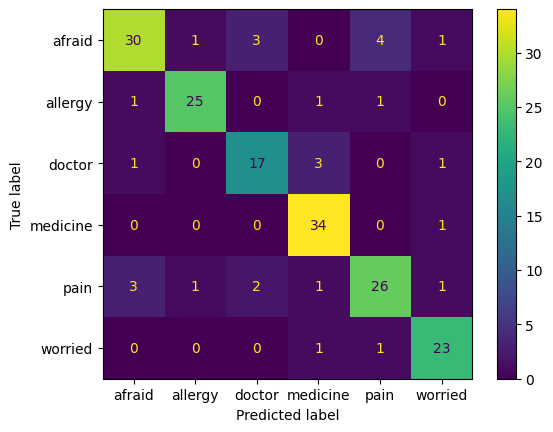

In [ ]:
history_res.model.load_weights('best_model_res.h5')

predictionsres=history_res.model.predict(x_test)

y_pred_classes = np.argmax(predictionsres, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm5 = confusion_matrix(y_true_classes, y_pred_classes)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=classes)
disp5.plot()

The results not quite good, we see way more false positives and negatives.

This is mainly because I used frozen weights, so most propably ResNet does not match my image's features.

But it is still better than the previous one


I wanted to also give another try to unfrozen weights.

So, as we said in class, I thought to only unfreeze the last layers so the model has the details it trained in a vast ammount of data, but take the broader features for this small dataset

In [ ]:
resNet=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in resNet.layers[:-7]:
    layer.trainable = False

model_res = Sequential()
model_res.add(resNet)

model_res.add(Flatten())
model_res.add(Dense(512, activation='relu'))
model_res.add(Dropout(0.5))

model_res.add(Dense(len(classes), activation='softmax'))

learning_rate = 0.00001
batch_size = 32
epochs = 80

adam = Adam(learning_rate=learning_rate)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
save_model_res = ModelCheckpoint('best_model_res.h5', save_best_only=True, monitor='val_loss', mode='min', verbose=2)
model_res.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_res = model_res.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, shuffle = True, verbose=1, validation_data=(x_val, y_val), callbacks=[save_model_res, early_stop])

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.2295 - loss: 2.2994
Epoch 1: val_loss improved from None to 1.80039, saving model to best_model_res.h5



Epoch 1: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 59s 5s/step - accuracy: 0.2635 - loss: 2.1199 - val_accuracy: 0.3203 - val_loss: 1.8004
Epoch 2/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3523 - loss: 1.6687
Epoch 2: val_loss improved from 1.80039 to 1.75105, saving model to best_model_res.h5



Epoch 2: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3851 - loss: 1.5753 - val_accuracy: 0.3203 - val_loss: 1.7510
Epoch 3/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4836 - loss: 1.3170
Epoch 3: val_loss improved from 1.75105 to 1.70813, saving model to best_model_res.h5



Epoch 3: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.5135 - loss: 1.2161 - val_accuracy: 0.2422 - val_loss: 1.7081
Epoch 4/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5827 - loss: 1.1251
Epoch 4: val_loss did not improve from 1.70813
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5811 - loss: 1.1032 - val_accuracy: 0.3047 - val_loss: 1.7189
Epoch 5/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6589 - loss: 0.9877
Epoch 5: val_loss improved from 1.70813 to 1.67204, saving model to best_model_res.h5



Epoch 5: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.6757 - loss: 0.9606 - val_accuracy: 0.2266 - val_loss: 1.6720
Epoch 6/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7720 - loss: 0.8119
Epoch 6: val_loss did not improve from 1.67204
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.7331 - loss: 0.8383 - val_accuracy: 0.3516 - val_loss: 1.6979
Epoch 7/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7691 - loss: 0.7380
Epoch 7: val_loss did not improve from 1.67204
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.7534 - loss: 0.7281 - val_accuracy: 0.2500 - val_loss: 1.6792
Epoch 8/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8495 - loss: 0.5789
Epoch 8: val_loss did not improve from 1.67204
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8209 - loss: 0.6446 - val_accuracy: 0.2891 - val_loss: 1.6738
Epoch 9/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8139 - loss: 0.60

...


Epoch 56: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9899 - loss: 0.0542 - val_accuracy: 0.8906 - val_loss: 0.2766
Epoch 57/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9931 - loss: 0.0427
Epoch 57: val_loss did not improve from 0.27660
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.9932 - loss: 0.0440 - val_accuracy: 0.9141 - val_loss: 0.2880
Epoch 58/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9936 - loss: 0.0355
Epoch 58: val_loss improved from 0.27660 to 0.26235, saving model to best_model_res.h5



Epoch 58: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9966 - loss: 0.0320 - val_accuracy: 0.8906 - val_loss: 0.2624
Epoch 59/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9765 - loss: 0.0517
Epoch 59: val_loss did not improve from 0.26235
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9797 - loss: 0.0525 - val_accuracy: 0.9141 - val_loss: 0.2864
Epoch 60/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9914 - loss: 0.0485
Epoch 60: val_loss did not improve from 0.26235
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.9865 - loss: 0.0619 - val_accuracy: 0.8750 - val_loss: 0.2933
Epoch 61/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9949 - loss: 0.0476
Epoch 61: val_loss improved from 0.26235 to 0.25606, saving model to best_model_res.h5



Epoch 61: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.9899 - loss: 0.0598 - val_accuracy: 0.9062 - val_loss: 0.2561
Epoch 62/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9931 - loss: 0.0419
Epoch 62: val_loss did not improve from 0.25606
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9932 - loss: 0.0420 - val_accuracy: 0.9141 - val_loss: 0.2910
Epoch 63/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9974 - loss: 0.0373
Epoch 63: val_loss did not improve from 0.25606
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.9966 - loss: 0.0391 - val_accuracy: 0.9141 - val_loss: 0.2639
Epoch 64/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9957 - loss: 0.0293
Epoch 64: val_loss did not improve from 0.25606
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.9932 - loss: 0.0367 - val_accuracy: 0.8984 - val_loss: 0.2741
Epoch 65/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9988 - lo


Epoch 69: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.9966 - loss: 0.0212 - val_accuracy: 0.9141 - val_loss: 0.2503
Epoch 70/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9974 - loss: 0.0219
Epoch 70: val_loss did not improve from 0.25029
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9932 - loss: 0.0232 - val_accuracy: 0.9219 - val_loss: 0.2933
Epoch 71/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.0167
Epoch 71: val_loss did not improve from 0.25029
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 1.0000 - loss: 0.0244 - val_accuracy: 0.9062 - val_loss: 0.2713
Epoch 72/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0179
Epoch 72: val_loss improved from 0.25029 to 0.24983, saving model to best_model_res.h5



Epoch 72: finished saving model to best_model_res.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 0.8984 - val_loss: 0.2498
Epoch 73/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.0170
Epoch 73: val_loss did not improve from 0.24983
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.8984 - val_loss: 0.2737
Epoch 74/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.0150
Epoch 74: val_loss did not improve from 0.24983
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 1.0000 - loss: 0.0164 - val_accuracy: 0.9062 - val_loss: 0.2622
Epoch 75/80
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.0127
Epoch 75: val_loss did not improve from 0.24983
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.9141 - val_loss: 0.2652
Epoch 76/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Accuracy: 0.9344262295081968
Recal: 0.9334157998863882
F1: 0.9325619939618911
Precision: 0.9333516872990556


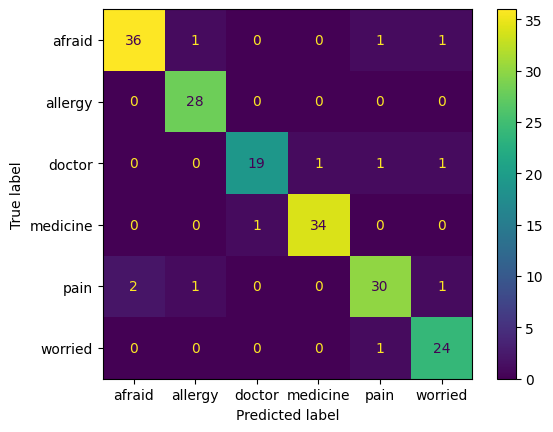

In [ ]:
history_res.model.load_weights('best_model_res.h5')

predictionsres=history_res.model.predict(x_test)

y_pred_classes = np.argmax(predictionsres, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

accuracy=accuracy_score(y_true_classes, y_pred_classes)
precision=precision_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
recall=recall_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)
f1=f1_score(y_true_classes, y_pred_classes, average='macro')# added macro because of error in compile (multiclass)

print(f"Accuracy: {accuracy}")
print(f"Recal: {recall}")
print(f"F1: {f1}") #f1 macro is what we want, micro is as accuracy
print(f"Precision: {precision}")

cm5 = confusion_matrix(y_true_classes, y_pred_classes)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=classes)
disp5.plot()

We a signifiant ammount of improvent over our first attempt at unfrozen weights and better with completely frozen ones, so unfreezing the last layers seems to be a good way of improving the model.

We add information, but keep the foundational knowledge.

With all the layers frozen as we did before, we use the resnet as is and add additional layer to get information from it, with the new method the model learns the broader features of our model and the last layer takes that information

As for the Evaluation of the model. Compared to our VGG:

All metrics seem to be worse. If we also look for overall false positives/negatives, they increased

If we look at specifically at the medicine and allergy classes we see interesting results

- medicine false negatives remain the same
- allergy false negatives actually dropped to 0

These results could worth considerating the tradeof of other classes missclassifications.

Whichever other class is missclassified can actually draw attention to surrounding people, but missclassifing medicine or allergy could proven lethal.

Of course we do take a big tradeoff, so ideally we would like to just improve the model overall rather than accepting this tradeof.

## Data augmentation

For data augmentation we will get our VGG network, as we would like to just improve medicine and allergy classes.

> Now as for the choices we have **image flipping is out of the question** because which hand is used, is essential and directly correlated for the word.

So we are left with:
- Image Rotation
- Image Zooming
- Image Height/Width Shifting
- Image Brightening/Darkening
- Channel Shifting

We will try all of them and in the end get the better result